# nnU-Net 2D — Test Inference

Runs ensemble prediction on the **test set** (`imagesTs/`) using trained folds.
No ground truth available — qualitative evaluation only.

| Cell | Purpose |
|---|---|
| 1 | Imports & setup |
| 2 | Paths & env vars |
| 3 | Check test cases |
| 4 | Run test inference (one-by-one, VRAM safe) |
| 5 | Case summary table |
| 6 | Select volume for visualization |
| 7 | Static overlay — top 4 tumor-dense slices |
| 8 | HTML animation — scroll through all slices |
| 9 | All tumor-containing slices grid |
| 10 | Tumor burden profile |
| 11 | Orthogonal views (axial/coronal/sagittal) |
| 12 | Per-slice class distribution |

In [39]:
## Cell 1 — Imports & Setup
import os
import json
import shutil
import subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from IPython.display import HTML, display
import nibabel as nib
from pathlib import Path

matplotlib.rcParams['animation.embed_limit'] = 100
print('✅ Imports done')

✅ Imports done


In [2]:
## Cell 2 — Paths & Env Vars
NNUNET_BASE    = r'C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data'
NNUNET_RAW     = os.path.join(NNUNET_BASE, 'nnUNet_raw')
NNUNET_PREP    = os.path.join(NNUNET_BASE, 'nnUNet_preprocessed')
NNUNET_RESULTS = os.path.join(NNUNET_BASE, 'nnUNet_results')
DATASET_ID     = '003'
DATASET_NAME   = f'Dataset{DATASET_ID}_Liver'
TRAINER        = 'nnUNetTrainer_500epochs'

os.environ['nnUNet_raw']          = NNUNET_RAW
os.environ['nnUNet_preprocessed'] = NNUNET_PREP
os.environ['nnUNet_results']      = NNUNET_RESULTS

ENSEMBLE_FOLDS = [0, 1, 2]   # ← extend to [0,1,2,3,4] once all folds done

TEST_INPUT  = Path(NNUNET_RAW) / DATASET_NAME / 'imagesTs'
TEST_OUTPUT = Path(NNUNET_RESULTS) / f'test_predictions_ensemble_{"_".join(map(str, ENSEMBLE_FOLDS))}'
TEST_OUTPUT.mkdir(exist_ok=True)

VIZ_BASE = Path(r'C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation') / 'visualizations'
VIZ_DIR  = VIZ_BASE / f'test_ensemble_{"_".join(map(str, ENSEMBLE_FOLDS))}'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

seg_cmap = ListedColormap(['lightgreen', 'red'])  # liver→green, tumor→red

print('✅ Setup complete')
print(f'Test input  : {TEST_INPUT}')
print(f'Test output : {TEST_OUTPUT}')
print(f'Viz dir     : {VIZ_DIR}')

✅ Setup complete
Test input  : C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_raw\Dataset003_Liver\imagesTs
Test output : C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_results\test_predictions_ensemble_0_1_2
Viz dir     : C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\test_ensemble_0_1_2


In [3]:
## Cell 3 — Check Test Cases
test_cases = sorted([
    f.name.replace('_0000.nii.gz', '')
    for f in TEST_INPUT.glob('*_0000.nii.gz')
])
already_done = {f.name.replace('.nii.gz', '') for f in TEST_OUTPUT.glob('*.nii.gz')}
remaining    = [c for c in test_cases if c not in already_done]

print(f'Total test cases : {len(test_cases)}')
print(f'Already done     : {len(already_done)}')
print(f'Remaining        : {len(remaining)}')
print(f'\nEnsemble folds   : {ENSEMBLE_FOLDS}')

Total test cases : 70
Already done     : 0
Remaining        : 70

Ensemble folds   : [0, 1, 2]


In [4]:
## Cell 4 — Run Test Inference (one-by-one, VRAM safe)
# ~1 min per case → ~70 min total for 70 cases
# Safe to re-run — skips already completed cases

temp_single = Path(NNUNET_BASE) / 'temp_single'
temp_single.mkdir(exist_ok=True)

predict_env = os.environ.copy()
predict_env['nnUNet_n_proc_DA'] = '2'
predict_env['OMP_NUM_THREADS']  = '1'
predict_env['ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS'] = '1'

already_done = {f.name.replace('.nii.gz', '') for f in TEST_OUTPUT.glob('*.nii.gz')}
remaining    = [c for c in test_cases if c not in already_done]
print(f'Already done: {len(already_done)}   Remaining: {len(remaining)}')

for i, case in enumerate(remaining):
    for f in temp_single.glob('*.nii.gz'):
        f.unlink()
    shutil.copy(
        TEST_INPUT / f'{case}_0000.nii.gz',
        temp_single / f'{case}_0000.nii.gz'
    )
    print(f'  [{i+1}/{len(remaining)}] Predicting {case}...', end=' ', flush=True)
    result = subprocess.run([
        'nnUNetv2_predict',
        '-i', str(temp_single),
        '-o', str(TEST_OUTPUT),
        '-d', DATASET_ID,
        '-c', '2d',
        '-f', *[str(f) for f in ENSEMBLE_FOLDS],
        '-tr', TRAINER,
        '-chk', 'checkpoint_best.pth',
    ], env=predict_env, capture_output=True, text=True)
    if (TEST_OUTPUT / f'{case}.nii.gz').exists():
        print('✅')
    else:
        print(f'❌  STDERR: {result.stderr[-200:]}')

print(f'\nDone. Total: {len(list(TEST_OUTPUT.glob("*.nii.gz")))}/{len(test_cases)}')

Already done: 0   Remaining: 70
  [1/70] Predicting liver_132... ✅
  [2/70] Predicting liver_133... ✅
  [3/70] Predicting liver_134... ✅
  [4/70] Predicting liver_135... ✅
  [5/70] Predicting liver_136... ✅
  [6/70] Predicting liver_137... ✅
  [7/70] Predicting liver_138... ✅
  [8/70] Predicting liver_139... ✅
  [9/70] Predicting liver_140... ✅
  [10/70] Predicting liver_141... ✅
  [11/70] Predicting liver_142... ✅
  [12/70] Predicting liver_143... ✅
  [13/70] Predicting liver_144... ✅
  [14/70] Predicting liver_145... ✅
  [15/70] Predicting liver_146... ✅
  [16/70] Predicting liver_147... ✅
  [17/70] Predicting liver_148... ✅
  [18/70] Predicting liver_149... ✅
  [19/70] Predicting liver_150... ✅
  [20/70] Predicting liver_151... ✅
  [21/70] Predicting liver_152... ✅
  [22/70] Predicting liver_153... ✅
  [23/70] Predicting liver_154... ✅
  [24/70] Predicting liver_155... ✅
  [25/70] Predicting liver_156... ✅
  [26/70] Predicting liver_157... ✅
  [27/70] Predicting liver_158... ✅
  [28

In [42]:
## Cell 5 — Case Summary Table
# ~2 min — loads all predictions to count voxels
pred_files = sorted(TEST_OUTPUT.glob('*.nii.gz'))
print(f'Found {len(pred_files)} test predictions\n')

print(f"{'Sr':<4}  {'Case':<14}  {'Shape':>16}  {'Size (MB)':>10}  {'Liver voxels':>14}  {'Tumor voxels':>14}  {'Tumor detected'}")
print('-' * 100)

test_summary = []
for i, pred_path in enumerate(pred_files):
    case_id   = pred_path.name.replace('.nii.gz', '')
    pred_nib  = nib.load(pred_path)
    pred_vol  = pred_nib.get_fdata().astype(np.uint8)
    shape     = pred_vol.shape
    size_mb   = pred_path.stat().st_size / 1e6
    liver_vox = ((pred_vol == 1) | (pred_vol == 2)).sum()
    tumor_vox = (pred_vol == 2).sum()
    detected  = '✅ Yes' if tumor_vox > 0 else '❌ No'
    shape_str = f'{shape[0]}x{shape[1]}x{shape[2]}'
    print(f'  {i:<3}  {case_id:<14}  {shape_str:>16}  {size_mb:>9.1f}  {liver_vox:>14,}  {tumor_vox:>14,}  {detected}')
    test_summary.append((i, case_id, liver_vox, tumor_vox, size_mb, shape))

print('-' * 100)
n_tumor = sum(1 for _, _, _, tv, _, _ in test_summary if tv > 0)
print(f'\nTumor detected in {n_tumor}/{len(pred_files)} cases')

Found 70 test predictions

Sr    Case                       Shape   Size (MB)    Liver voxels    Tumor voxels  Tumor detected
----------------------------------------------------------------------------------------------------
  0    liver_132            512x512x163        0.1         682,959             735  ✅ Yes
  1    liver_133            512x512x249        0.1         790,817          52,949  ✅ Yes
  2    liver_134            512x512x205        0.1       1,490,743              64  ✅ Yes
  3    liver_135            512x512x208        0.1       1,214,408             611  ✅ Yes
  4    liver_136             512x512x97        0.1         803,934              72  ✅ Yes
  5    liver_137            512x512x107        0.1         737,637          34,916  ✅ Yes
  6    liver_138             512x512x89        0.0         759,684             818  ✅ Yes
  7    liver_139            512x512x147        0.1         972,466           1,508  ✅ Yes
  8    liver_140             512x512x97        0.1   

In [52]:
## Cell 6 — Select Volume for Visualization
# Change VOLUME_IDX to any Sr No from Cell 5 table
# Add after VIZ_DIR definition
# NOTE: Liver mask may appear on both sides of the CT slice — this is anatomically correct.
# The liver has two lobes (right lobe larger, left lobe smaller) which can appear as
# separate green regions in axial slices. Verified: mean HU ~73.4 in masked region,
# consistent with contrast-enhanced liver parenchyma (expected 50-70 HU, slightly
# elevated in contrast CT). Not a false positive.
VOLUME_IDX = 0   # ← change to any Sr No from Cell 5 table

_, vol_name, liver_vox, tumor_vox, size_mb, vol_shape = test_summary[VOLUME_IDX]
print(f'Selected  : {vol_name}  (Sr {VOLUME_IDX})')
print(f'Shape     : {vol_shape[0]}x{vol_shape[1]}x{vol_shape[2]}')
print(f'Size      : {size_mb:.1f} MB')
print(f'Liver vox : {liver_vox:,}')
print(f'Tumor vox : {tumor_vox:,}')

# Per-volume viz subfolder
VOL_VIZ_DIR = VIZ_DIR / vol_name
VOL_VIZ_DIR.mkdir(exist_ok=True)
print(f'Vol viz dir : {VOL_VIZ_DIR}')

# Load CT and prediction
ct_vol   = nib.load(TEST_INPUT  / f'{vol_name}_0000.nii.gz').get_fdata()
pred_vol = nib.load(TEST_OUTPUT / f'{vol_name}.nii.gz').get_fdata().astype(np.uint8)

# HU windowing
ct_disp = np.clip(ct_vol, -100, 400)
ct_disp = (ct_disp - ct_disp.min()) / (ct_disp.max() - ct_disp.min())

# Per-slice counts
n_slices     = pred_vol.shape[2]
tumor_counts = [(pred_vol[:, :, z] == 2).sum() for z in range(n_slices)]
liver_counts = [((pred_vol[:, :, z] == 1) | (pred_vol[:, :, z] == 2)).sum() for z in range(n_slices)]
bg_counts    = [(pred_vol[:, :, z] == 0).sum() for z in range(n_slices)]

tumor_slice_indices = [z for z in range(n_slices) if tumor_counts[z] > 0]
top_slices = sorted(range(n_slices), key=lambda z: tumor_counts[z], reverse=True)

if max(tumor_counts) == 0:
    print('  ⚠️  No tumor detected — using liver-dense slices')
    top_slices = sorted(range(n_slices), key=lambda z: liver_counts[z], reverse=True)

print(f'\nTotal slices     : {n_slices}')
print(f'Liver slices     : {sum(1 for l in liver_counts if l > 0)}')
print(f'Tumor slices     : {len(tumor_slice_indices)}')
print(f'Most tumor-dense : slice {top_slices[0]}  ({tumor_counts[top_slices[0]]} px)')

Selected  : liver_132  (Sr 0)
Shape     : 512x512x163
Size      : 0.1 MB
Liver vox : 682,959
Tumor vox : 735
Vol viz dir : C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\test_ensemble_0_1_2\liver_132

Total slices     : 163
Liver slices     : 45
Tumor slices     : 10
Most tumor-dense : slice 109  (157 px)


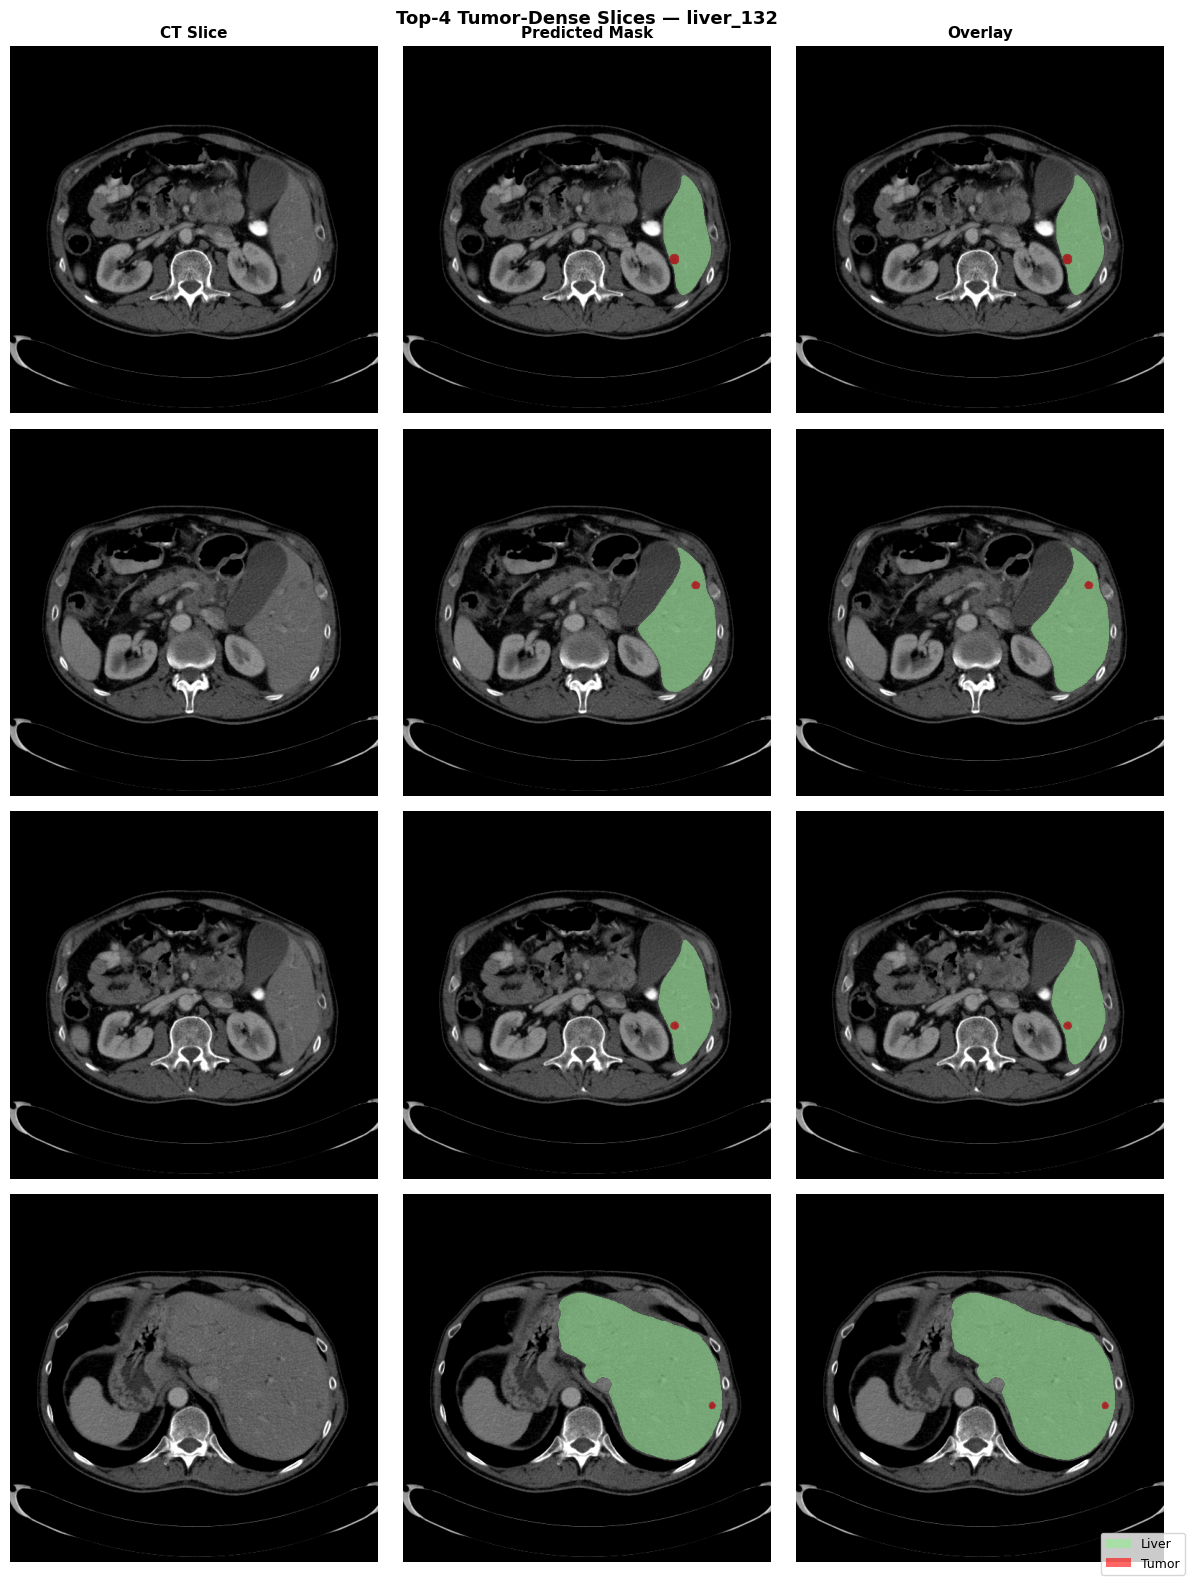

Saved → C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\test_ensemble_0_1_2\liver_132\liver_132_top4_slices.png


In [53]:
## Cell 7 — Static Overlay — Top 4 Tumor-Dense Slices
# ~5 seconds
n_show   = 4
show_idx = top_slices[:n_show]

fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 4))
fig.suptitle(f'Top-{n_show} Tumor-Dense Slices — {vol_name}', fontsize=13, fontweight='bold')

col_titles = ['CT Slice', 'Predicted Mask', 'Overlay']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=11, fontweight='bold')

for row, z in enumerate(show_idx):
    ct_slice   = ct_disp[:, :, z].T
    pred_slice = pred_vol[:, :, z].T
    tumor_px   = tumor_counts[z]
    liver_px   = liver_counts[z]

    axes[row, 0].imshow(ct_slice, cmap='gray', origin='lower')
    axes[row, 0].set_ylabel(f'Slice {z}\nliver={liver_px}px\ntumor={tumor_px}px', fontsize=8)
    axes[row, 1].imshow(ct_slice, cmap='gray', origin='lower')
    axes[row, 1].imshow(np.ma.masked_where(pred_slice == 0, pred_slice),
                        cmap=seg_cmap, alpha=0.5, vmin=1, vmax=2, origin='lower')
    axes[row, 2].imshow(ct_slice, cmap='gray', origin='lower')
    axes[row, 2].imshow(np.ma.masked_where(pred_slice == 0, pred_slice),
                        cmap=seg_cmap, alpha=0.5, vmin=1, vmax=2, origin='lower')
    for ax in axes[row]:
        ax.axis('off')

legend_elements = [
    Patch(facecolor='lightgreen', alpha=0.6, label='Liver'),
    Patch(facecolor='red',        alpha=0.6, label='Tumor'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
out_path = VOL_VIZ_DIR / f'{vol_name}_top4_slices.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

In [54]:
## Cell 8 — HTML Animation — Scroll Through All Slices
# ~30-60 seconds depending on volume size

step = 2   # ← 1=every slice (slow), 2=every other slice (faster)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))  
plt.subplots_adjust(top=0.85)

z0    = 0
ct0   = ct_disp[:, :, z0].T
pred0 = pred_vol[:, :, z0].T

im_ct   = axes[0].imshow(ct0, cmap='gray', origin='lower', animated=True)
im_base = axes[1].imshow(ct0, cmap='gray', origin='lower', animated=True)
im_ov   = axes[1].imshow(np.ma.masked_where(pred0 == 0, pred0),
                          cmap=seg_cmap, alpha=0.5, vmin=1, vmax=2,
                          origin='lower', animated=True)

axes[0].set_title('CT Slice', fontsize=11, fontweight='bold')
axes[1].set_title('Overlay',  fontsize=11, fontweight='bold')
for ax in axes:
    ax.axis('off')
title = fig.suptitle('', fontsize=11, fontweight='bold')

def update(z):
    ct_s     = ct_disp[:, :, z].T
    pred_s   = pred_vol[:, :, z].T
    tumor_px = int(tumor_counts[z])
    liver_px = int(liver_counts[z])
    tumor_label = '  [TUMOR]' if tumor_px > 0 else ''
    im_ct.set_data(ct_s)
    im_base.set_data(ct_s)
    im_ov.set_data(np.ma.masked_where(pred_s == 0, pred_s))
    title.set_text(f'{vol_name}  —  Slice {z+1}/{n_slices}{tumor_label}\n'
                   f'liver={liver_px}px  |  tumor={tumor_px}px')
    return im_ct, im_base, im_ov, title

frames = range(0, n_slices, step)
anim   = FuncAnimation(fig, update, frames=frames, interval=120, blit=True)
plt.close()
display(HTML(anim.to_jshtml()))

html_path = VOL_VIZ_DIR / f'{vol_name}_animation.html'
with open(html_path, 'w') as f:
    f.write(anim.to_jshtml())
print(f'Saved → {html_path}')
print(f'Animation: {len(list(frames))} frames  |  step={step}')

Saved → C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\test_ensemble_0_1_2\liver_132\liver_132_animation.html
Animation: 82 frames  |  step=2


Tumor detected in 10 slices: [109, 110, 111, 115, 116, 120, 128, 129, 133, 134]



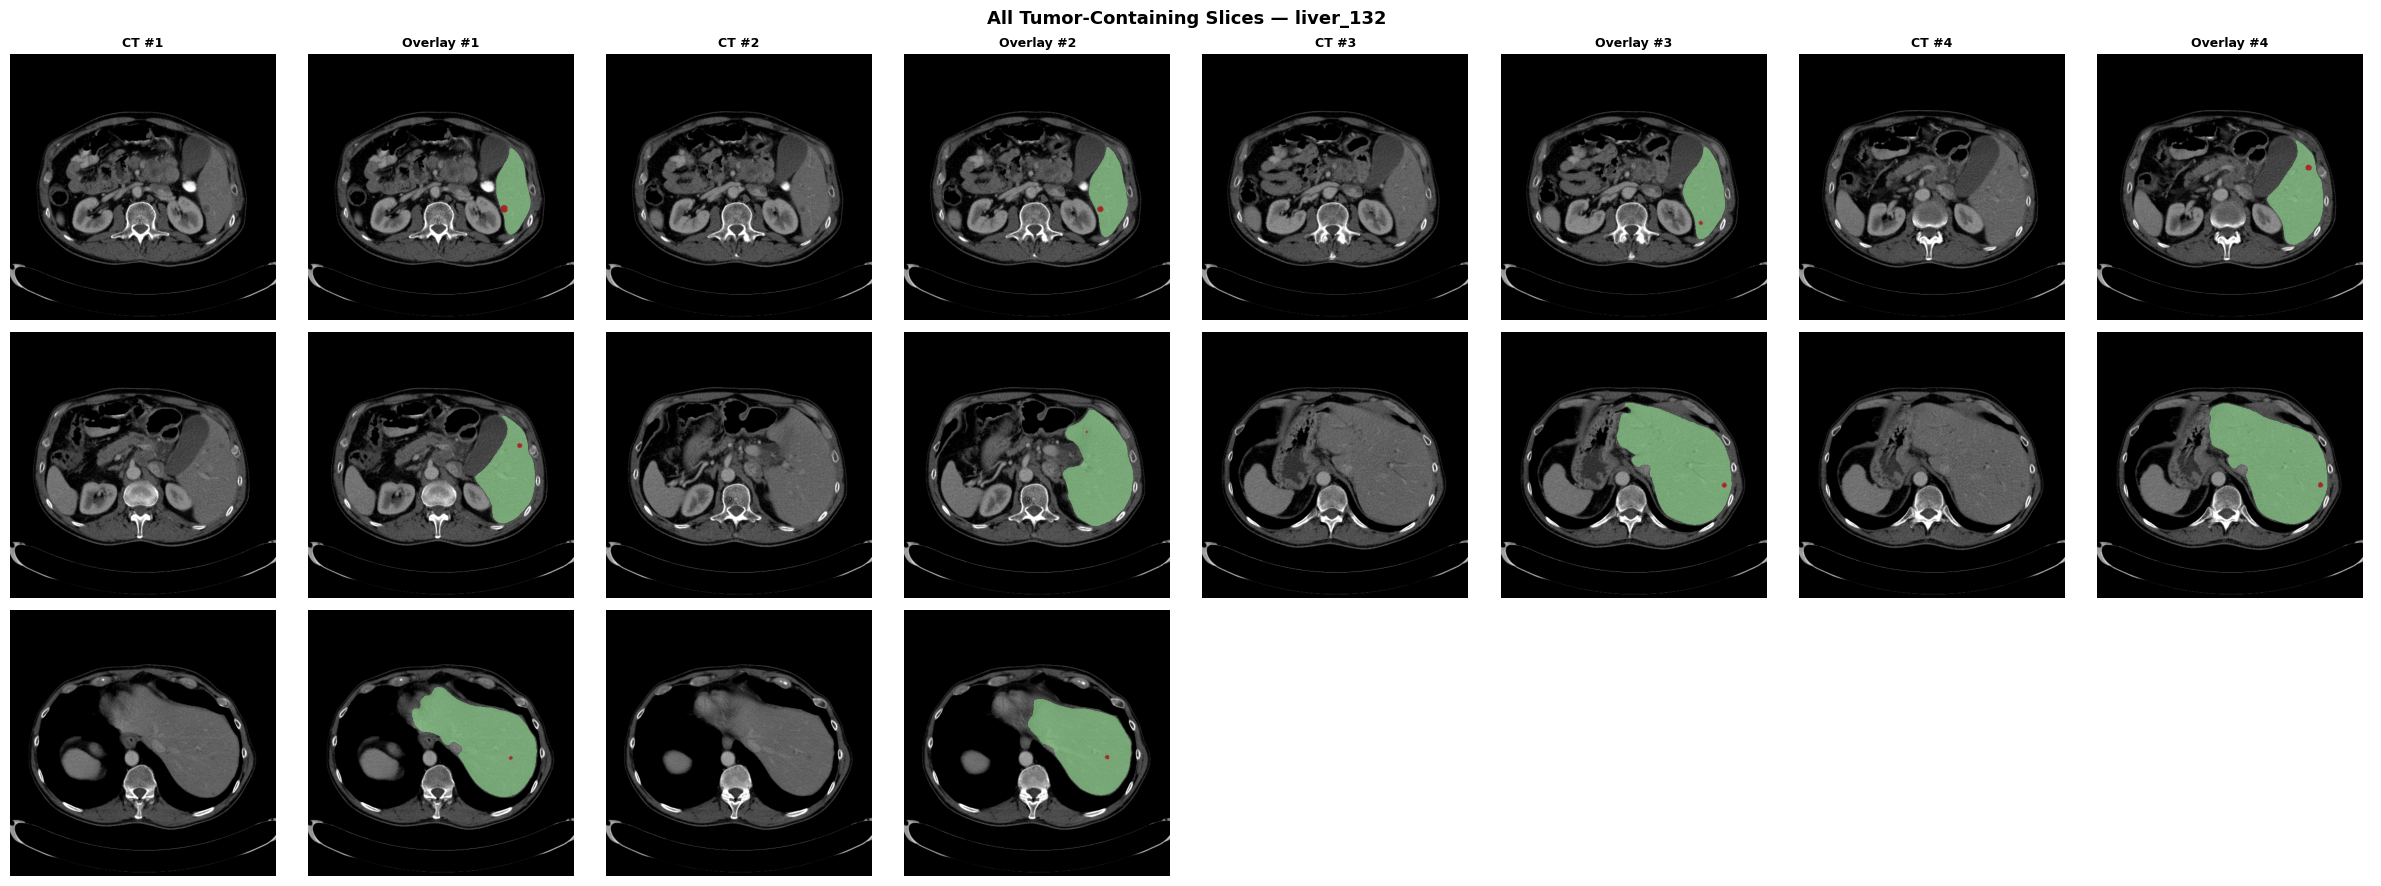

Saved → C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\test_ensemble_0_1_2\liver_132\liver_132_all_tumor_slices.png


In [55]:
## Cell 9 — All Tumor-Containing Slices Grid
# ~10 seconds

print(f'Tumor detected in {len(tumor_slice_indices)} slices: {tumor_slice_indices}\n')

if len(tumor_slice_indices) == 0:
    print('No tumor predicted in this volume.')
else:
    n_cols = 4
    n_rows = (len(tumor_slice_indices) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(n_cols * 2 * 3, n_rows * 3))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f'All Tumor-Containing Slices — {vol_name}', fontsize=13, fontweight='bold')

    for col in range(n_cols):
        axes[0, col*2  ].set_title(f'CT #{col+1}',      fontsize=9, fontweight='bold')
        axes[0, col*2+1].set_title(f'Overlay #{col+1}', fontsize=9, fontweight='bold')

    for idx, z in enumerate(tumor_slice_indices):
        row      = idx // n_cols
        col_base = (idx %  n_cols) * 2
        ct_s     = ct_disp[:, :, z].T
        pred_s   = pred_vol[:, :, z].T
        tumor_px = int(tumor_counts[z])

        axes[row, col_base].imshow(ct_s, cmap='gray', origin='lower')
        axes[row, col_base].set_ylabel(f'Slice {z}\ntumor={tumor_px}px', fontsize=7)
        axes[row, col_base+1].imshow(ct_s, cmap='gray', origin='lower')
        axes[row, col_base+1].imshow(np.ma.masked_where(pred_s == 0, pred_s),
                                      cmap=seg_cmap, alpha=0.5, vmin=1, vmax=2, origin='lower')
        axes[row, col_base  ].axis('off')
        axes[row, col_base+1].axis('off')

    for idx in range(len(tumor_slice_indices), n_rows * n_cols):
        row = idx // n_cols
        col_base = (idx % n_cols) * 2
        axes[row, col_base  ].axis('off')
        axes[row, col_base+1].axis('off')

    plt.tight_layout()
    out_path = VOL_VIZ_DIR / f'{vol_name}_all_tumor_slices.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')

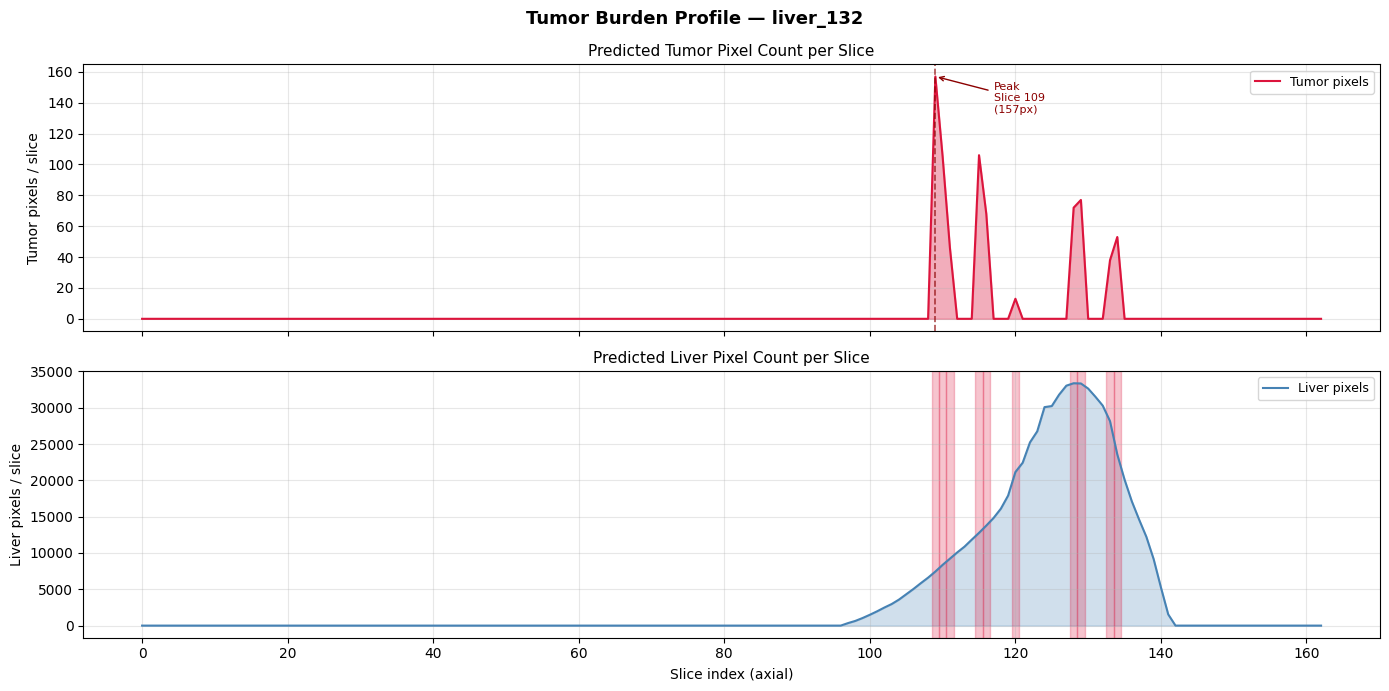

Saved → C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\test_ensemble_0_1_2\liver_132\liver_132_burden_profile.png


In [56]:
## Cell 10 — Tumor Burden Profile
slice_indices = np.arange(n_slices)
tumor_px_arr  = np.array(tumor_counts)
liver_px_arr  = np.array(liver_counts)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f'Tumor Burden Profile — {vol_name}', fontsize=13, fontweight='bold')

axes[0].fill_between(slice_indices, tumor_px_arr, alpha=0.35, color='crimson')
axes[0].plot(slice_indices, tumor_px_arr, color='crimson', linewidth=1.5, label='Tumor pixels')
axes[0].set_ylabel('Tumor pixels / slice', fontsize=10)
axes[0].set_title('Predicted Tumor Pixel Count per Slice', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

if max(tumor_counts) > 0:
    peak_z  = top_slices[0]
    peak_px = tumor_counts[peak_z]
    axes[0].axvline(peak_z, color='darkred', linestyle='--', linewidth=1.2, alpha=0.7)
    axes[0].annotate(f'Peak\nSlice {peak_z}\n({peak_px}px)',
                     xy=(peak_z, peak_px),
                     xytext=(peak_z + max(3, n_slices//20), peak_px * 0.85),
                     fontsize=8, color='darkred',
                     arrowprops=dict(arrowstyle='->', color='darkred', lw=1.0))

axes[1].fill_between(slice_indices, liver_px_arr, alpha=0.25, color='steelblue')
axes[1].plot(slice_indices, liver_px_arr, color='steelblue', linewidth=1.5, label='Liver pixels')
axes[1].set_ylabel('Liver pixels / slice', fontsize=10)
axes[1].set_xlabel('Slice index (axial)', fontsize=10)
axes[1].set_title('Predicted Liver Pixel Count per Slice', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

for z in tumor_slice_indices:
    axes[1].axvspan(z - 0.5, z + 0.5, color='crimson', alpha=0.25)

plt.tight_layout()
out_path = VOL_VIZ_DIR / f'{vol_name}_burden_profile.png'
plt.savefig(out_path, dpi=150)
plt.show()
print(f'Saved → {out_path}')

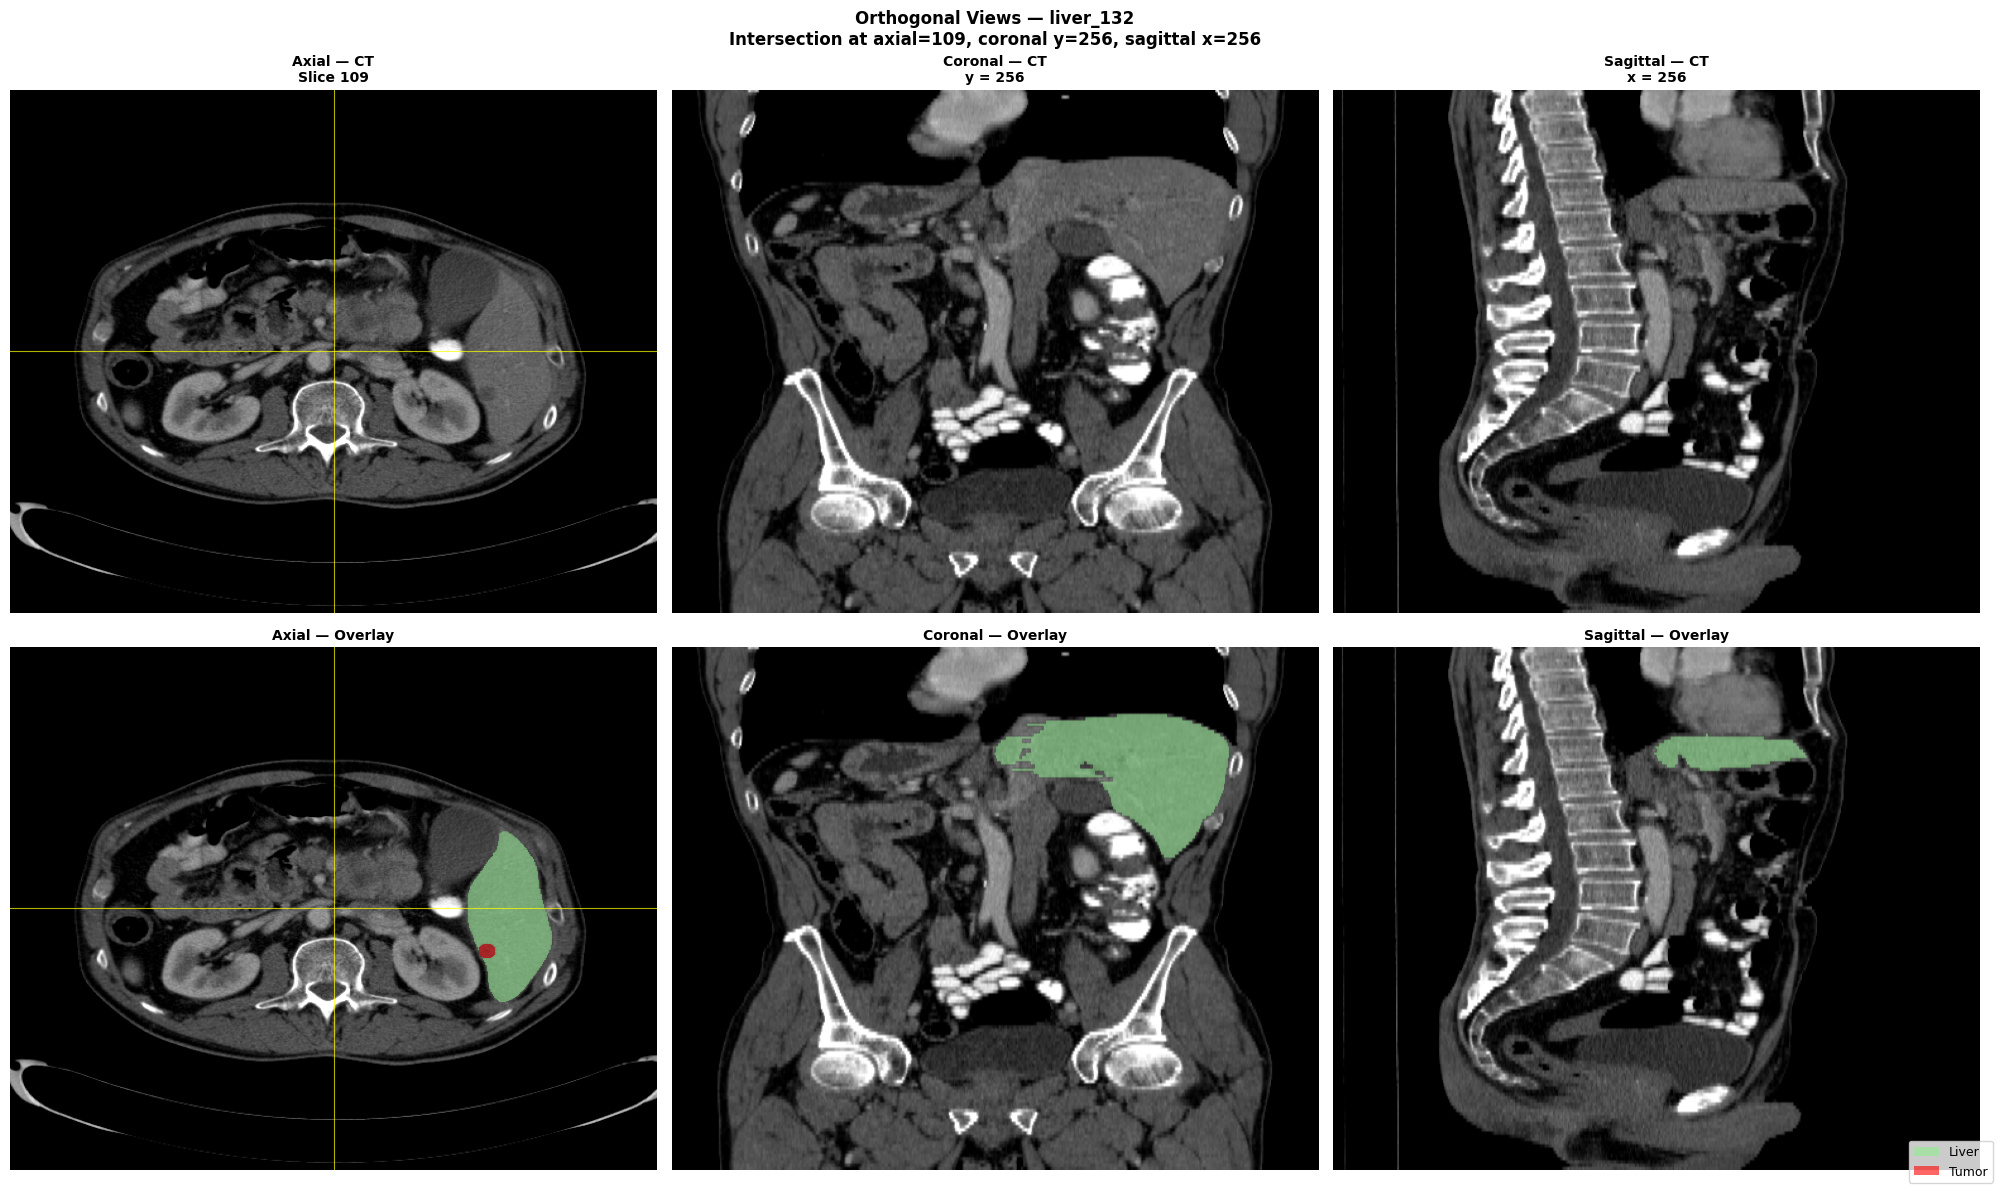

Saved → C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\test_ensemble_0_1_2\liver_132\liver_132_orthogonal_views.png


In [57]:
## Cell 11 — Orthogonal Views (Axial / Coronal / Sagittal)
ct_3d   = ct_disp
pred_3d = pred_vol

z_mid = top_slices[0]
y_mid = ct_3d.shape[1] // 2
x_mid = ct_3d.shape[0] // 2

axial_ct      = ct_3d[:, :, z_mid].T
axial_pred    = pred_3d[:, :, z_mid].T
coronal_ct    = ct_3d[:, y_mid, :].T
coronal_pred  = pred_3d[:, y_mid, :].T
sagittal_ct   = ct_3d[x_mid, :, :].T
sagittal_pred = pred_3d[x_mid, :, :].T

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    f'Orthogonal Views — {vol_name}\n'
    f'Intersection at axial={z_mid}, coronal y={y_mid}, sagittal x={x_mid}',
    fontsize=12, fontweight='bold'
)

view_data = [
    ('Axial',    f'Slice {z_mid}', axial_ct,    axial_pred),
    ('Coronal',  f'y = {y_mid}',   coronal_ct,  coronal_pred),
    ('Sagittal', f'x = {x_mid}',   sagittal_ct, sagittal_pred),
]

for col, (view_name, subtitle, ct_view, pred_view) in enumerate(view_data):
    axes[0, col].imshow(ct_view, cmap='gray', aspect='auto', origin='lower')
    axes[0, col].set_title(f'{view_name} — CT\n{subtitle}', fontsize=10, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(ct_view, cmap='gray', aspect='auto', origin='lower')
    axes[1, col].imshow(np.ma.masked_where(pred_view == 0, pred_view),
                        cmap=seg_cmap, alpha=0.5, vmin=1, vmax=2,
                        aspect='auto', origin='lower')
    axes[1, col].set_title(f'{view_name} — Overlay', fontsize=10, fontweight='bold')
    axes[1, col].axis('off')

for row in range(2):
    axes[row, 0].axhline(y_mid, color='yellow', linewidth=0.8, alpha=0.7)
    axes[row, 0].axvline(x_mid, color='yellow', linewidth=0.8, alpha=0.7)

legend_elements = [
    Patch(facecolor='lightgreen', alpha=0.6, label='Liver'),
    Patch(facecolor='red',        alpha=0.6, label='Tumor'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
out_path = VOL_VIZ_DIR / f'{vol_name}_orthogonal_views.png'
plt.savefig(out_path, dpi=300)
plt.show()
print(f'Saved → {out_path}')

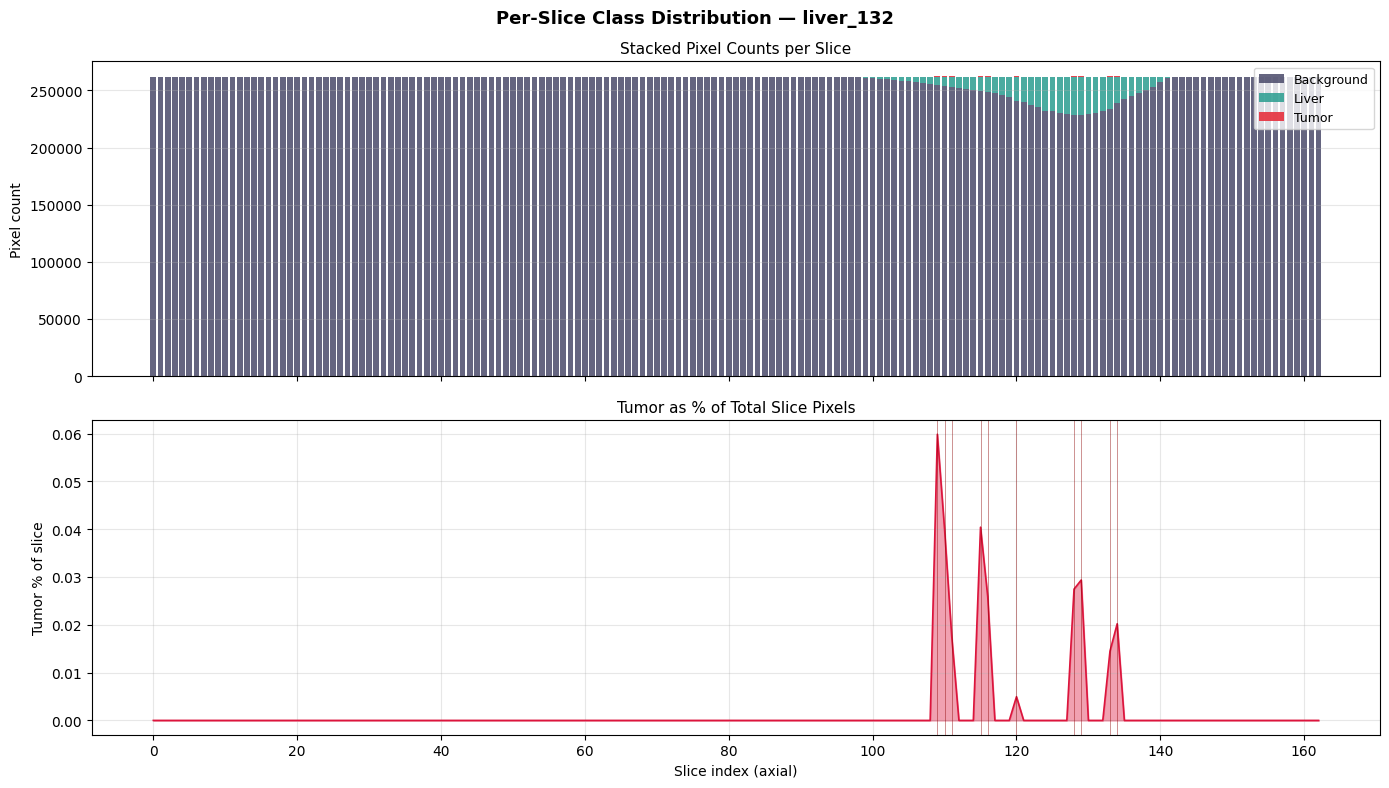

Saved → C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\test_ensemble_0_1_2\liver_132\liver_132_class_distribution.png


In [58]:
## Cell 12 — Per-Slice Class Distribution
bg_arr    = np.array(bg_counts)
liver_arr = np.array(liver_counts)
tumor_arr = np.array(tumor_counts)
x         = np.arange(n_slices)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'Per-Slice Class Distribution — {vol_name}', fontsize=13, fontweight='bold')

axes[0].bar(x, bg_arr,    label='Background', color='#4a4a6a', alpha=0.85)
axes[0].bar(x, liver_arr, label='Liver',      color='#2a9d8f', alpha=0.85, bottom=bg_arr)
axes[0].bar(x, tumor_arr, label='Tumor',      color='#e63946', alpha=0.95, bottom=bg_arr + liver_arr)
axes[0].set_ylabel('Pixel count', fontsize=10)
axes[0].set_title('Stacked Pixel Counts per Slice', fontsize=11)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

total_px  = bg_arr + liver_arr + tumor_arr
tumor_pct = np.where(total_px > 0, tumor_arr / total_px * 100, 0)

axes[1].fill_between(x, tumor_pct, alpha=0.4, color='crimson')
axes[1].plot(x, tumor_pct, color='crimson', linewidth=1.2)
axes[1].set_ylabel('Tumor % of slice', fontsize=10)
axes[1].set_xlabel('Slice index (axial)', fontsize=10)
axes[1].set_title('Tumor as % of Total Slice Pixels', fontsize=11)
axes[1].grid(True, alpha=0.3)

for z in tumor_slice_indices:
    axes[1].axvline(z, color='darkred', linewidth=0.6, alpha=0.5)

plt.tight_layout()
out_path = VOL_VIZ_DIR / f'{vol_name}_class_distribution.png'
plt.savefig(out_path, dpi=150)
plt.show()
print(f'Saved → {out_path}')